# Modules and data import

In [1]:
# For online projects files edits and no kernel and modules reloaded
%load_ext autoreload
%autoreload 2

In [2]:
%reload_ext autoreload
# %pip install -U pip

In [ ]:
import pandas as pd

# Load initially processed data
oil, stores, transactions, sales, X_exog_train, X_exog_test = (
    pd.read_parquet("../data/processed/oil.pq"),
    pd.read_parquet("../data/processed/stores.pq"),
    pd.read_parquet("../data/processed/transactions.pq"),
    pd.read_parquet("../data/processed/sales.pq"),
    pd.read_parquet("../data/processed/sales_exog_train.pq"),
    pd.read_parquet("../data/processed/sales_exog_test.pq"),
)

In [4]:
import megatron.config as config

# Set global config variables for running session
config.set_config(
    SEASONAL_PERIOD=7,
    MAX_LAG_W_SIZE=30,
    COUNTRY="EC",
    MIN_DATE=oil.index.min(),
    MAX_DATE=oil.index.max(),
    FH_SIZE=X_exog_test.index.get_level_values(-1).nunique(),
)

from megatron.transformers.additional import Mapper, DemandClassifier
from megatron.transformers.series import (
    ChangePointDetector,
    PlateauDetector,
    OutlierDetector,
    ExogenousDataTransformer,
)
from megatron.clusterers.series import (
    SmoothErraticClusterer,
    IntermittentLumpyClusterer,
)
from megatron.forecasters.series import CommonForecaster
from megatron.pipelines.series import E2EForecaster
from megatron.visualization.series import (
    seriesPlot,
    clusteredSeriesPlot,
    forecastedSeriesPlot,
)

from sktime.forecasting.base import ForecastingHorizon
import plotly.express as px
import plotly.io as pio
from pathlib import Path
from joblib import dump, load

fh = ForecastingHorizon(values=[*range(1, config.FH_SIZE + 1)], is_relative=True, freq="D")  # type: ignore
px.defaults.width, px.defaults.height = config.FIG_WIDTH, config.FIG_HEIGHT  # type: ignore
pio.renderers.default = "svg"

# Exogenous features

## Transactions

In [ ]:
# Since transctions data're avaliable only on train period fitting an intermediate
# forecasting model is requied in order to use this data as a complete
# exogenous variable for the main model quality enhancement

# Proposed solution disclosing CommonPipeline stepwise strategy

temp = transactions.copy()
temp.head()

transactions
store_nbr date                    
1         2015-08-31        1785.0
          2015-09-01        1769.0
          2015-09-02        1892.0
          2015-09-03        1744.0
          2015-09-04        1771.0

### Exogenous data

In [ ]:
# Exogenous data for both train and test perionds construction
X_temp_train = X_exog_train.groupby(["store_nbr", "date"]).sum().join(oil).join(stores)
X_temp_test = X_exog_test.groupby(["store_nbr", "date"]).sum().join(oil).join(stores)

X_temp_train.head()

on_promotion    oil  type  store_group
store_nbr date                                              
1         2015-08-31          23.0  49.20   0.0         13.0
          2015-09-01          23.0  45.38   0.0         13.0
          2015-09-02         213.0  46.30   0.0         13.0
          2015-09-03          10.0  46.75   0.0         13.0
          2015-09-04         182.0  46.02   0.0         13.0

### Multiindex reduction

In [7]:
# Replacing multiindex with a single index to avoid further pandas index manipulation issues
mapper = Mapper()
temp = mapper.fit_transform(temp)
X_temp_train = mapper.transform(X_temp_train)
X_temp_test = mapper.transform(X_temp_test)

### Classification

In [ ]:
# Series behavior classification to define an appropriate processing and modeling
result = DemandClassifier().fit_transform(temp)
result["class"].value_counts()  # type: ignore

class
smooth    54
Name: count, dtype: int64

In [9]:
demand, value = "smooth", "transactions"

### Plateau detection

In [ ]:
# Defining a temporal inactivity expressed as a plateau - zero values sequence with
# a specific length and leave only data which follows the last plateau if any defined
pld = PlateauDetector(w=2 * config.SEASONAL_PERIOD, value=0, truncate=True)  # type: ignore
temp = pld.fit_transform(temp)

### Change point detection

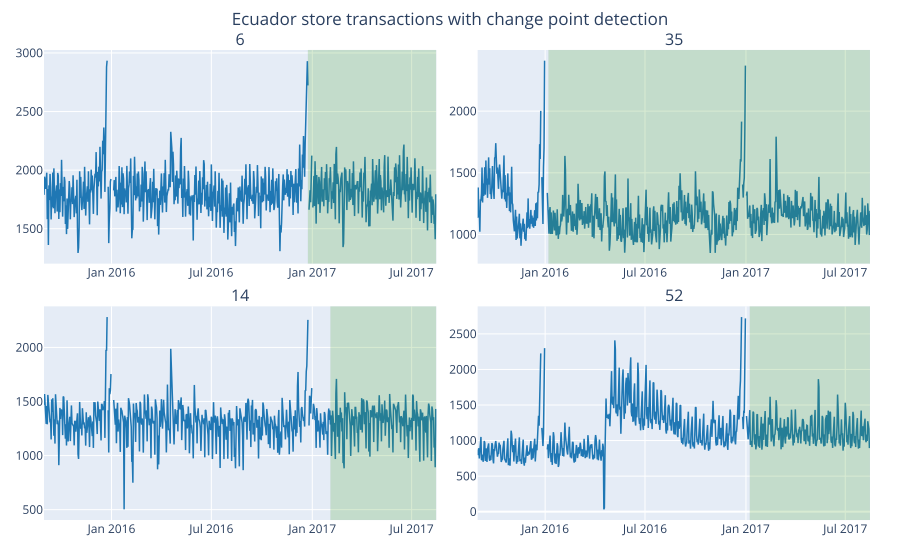

In [ ]:
# Defining an inflection point with specific requirements where the most significant
# trend behavior change was occured
seriesPlot(
    data=temp,  # type: ignore
    demand=demand,
    n_series=4,
    title=f"Ecuador store {value} with change point detection",
    w=config.MIN_LENGTH,  # type: ignore
    cpd=True,
    seed=555,
)

In [12]:
# Leave only data which follows right after this point if any exists
cpd = ChangePointDetector(w=config.MIN_LENGTH, truncate=True)  # type: ignore
temp = cpd.fit_transform(temp)

### Outliers detection

In [ ]:
# Defining outliers as a significant temporal demand with holidays and promotions
# data taking into account and remove selected points that are not related to holidays
# and promotion days
od = OutlierDetector(demand=demand, exog_column="on_promotion", truncate=True)
temp = od.fit_transform(temp.join(X_temp_train))  # type: ignore

### Missing values imputation

In [14]:
# Interpolating missing values if any present
index = temp.index  # type: ignore
temp = temp.groupby(index.names[0]).transform(  # type: ignore
    lambda x: x.interpolate(method="linear").bfill().ffill()
)

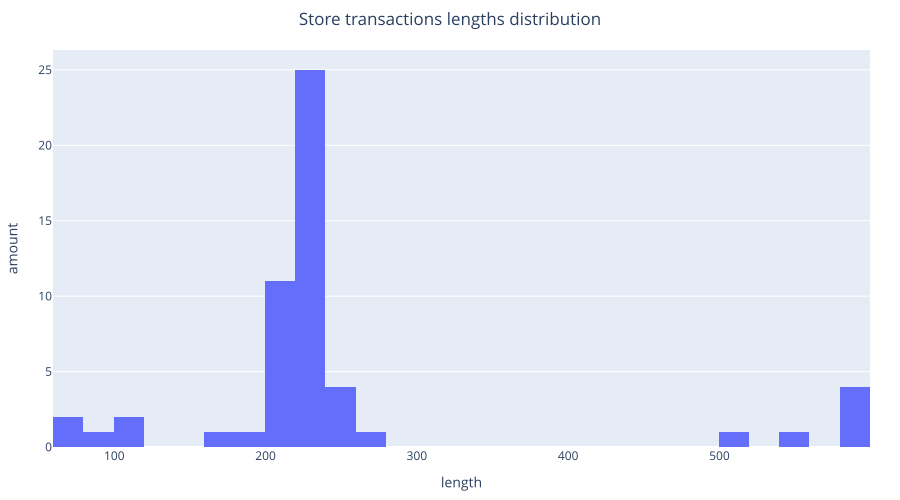

In [15]:
px.histogram(x=temp.groupby(index.names[0]).size(), nbins=50).update_layout(  # type: ignore
    margin=config.MARGIN,  # type: ignore
    title={
        "text": f"Store {value} lengths distribution",
        "x": 0.5,
    },
    xaxis_title="length",
    yaxis_title="amount",
)

### Exogenous data transformation

In [16]:
# Expanding exogenous data with additional features based on the date index
ft = ExogenousDataTransformer()
X_temp_train = ft.fit_transform(X_temp_train)
X_temp_test = ft.transform(X_temp_test)
X_temp_train.head()  # type: ignore

on_promotion    oil  type  store_group  month_of_year  \
index date                                                                
0     2015-08-31          23.0  49.20   0.0         13.0            8.0   
      2015-09-01          23.0  45.38   0.0         13.0            9.0   
      2015-09-02         213.0  46.30   0.0         13.0            9.0   
      2015-09-03          10.0  46.75   0.0         13.0            9.0   
      2015-09-04         182.0  46.02   0.0         13.0            9.0   

                  day_of_month  day_of_week  is_weekend  is_holiday  is_wage  
index date                                                                    
0     2015-08-31          31.0          0.0         0.0         0.0      1.0  
      2015-09-01           1.0          1.0         0.0         0.0      0.0  
      2015-09-02           2.0          2.0         0.0         0.0      0.0  
      2015-09-03           3.0          3.0         0.0         0.0      0.0  
      2015-09-04           4.0          4.0         0.0         0.0      0.0

### Clustering

In [17]:
# Aligning exogenous variables with target by index
X_temp_train = temp[[]].join(X_temp_train)

In [ ]:
# Clustering series with similar shape, statistics and magnitude to enhance the
# global forecasting quality per cluster
clusterer = SmoothErraticClusterer(w=90)

dir_path = Path.cwd().parent / "models"
path = dir_path / (
    "_".join([value, demand, clusterer.get_tag("object_type")])  # type: ignore
    + ".joblib"
)

if not Path.is_file(path):
    clusterer.fit(X=temp)
    dump(clusterer, path)
else:
    clusterer = load(path)

clusterer.metrics

,avg_sil_score,avg_ari,std_ari,std_inertia,score
4,0.380804,1.000000,0.000000,0.000000,1.190402
5,0.366861,0.999360,0.004483,1.370659,1.164601
3,0.370308,0.989776,0.024466,0.512182,1.145342
6,0.340955,0.940157,0.084733,4.147799,0.984423
7,0.306724,0.907867,0.083028,3.256614,0.945635


In [19]:
# Assigning cluster labels to instances as a primary index
labels = pd.Series(clusterer.labels, name="cluster").rename_axis("index")
temp = (
    temp.join(labels)
    .set_index("cluster", append=True)
    .reorder_levels(["cluster"] + index.names)  # type: ignore
    .sort_index()
)
X_temp_train = temp[[]].join(X_temp_train)
X_temp_test = (
    X_temp_test.join(labels)  # type: ignore
    .set_index("cluster", append=True)
    .reorder_levels(["cluster"] + index.names)  # type: ignore
    .sort_index()
)
labels.value_counts()

cluster
3    21
2    14
0    11
1     8
Name: count, dtype: int64

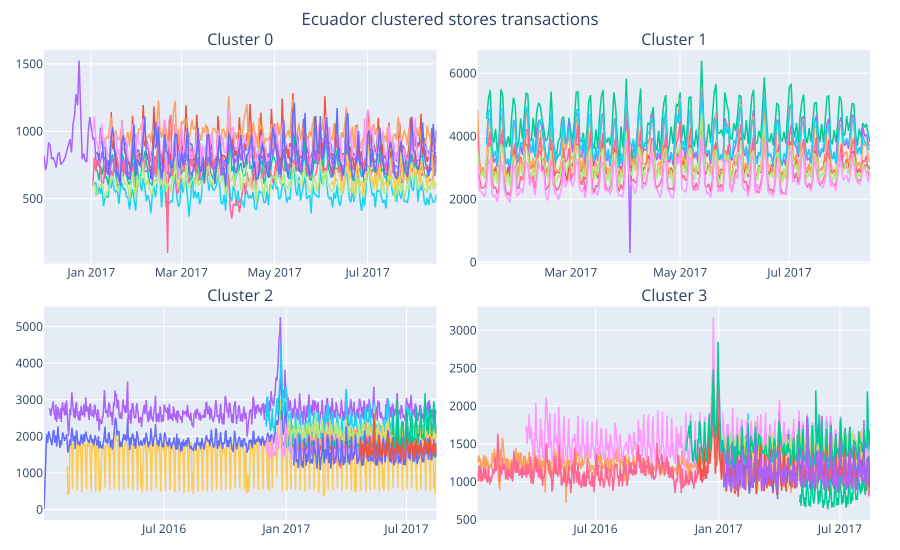

In [20]:
# Visualizing clusters in order to evaluate homogeneity of their instances
clusteredSeriesPlot(data=temp, title=f"Ecuador clustered stores {value}")

In [21]:
temp.groupby("cluster").size().sort_values(ascending=False)

cluster
3    5590
2    3812
0    2334
1    1744
dtype: int64

### Modeling

In [ ]:
# Fitting forecasting model per cluster based on its size and with all exogenous
# data accomodation
forecaster = CommonForecaster(dir_path=dir_path, value=value, demand=demand)
forecaster.fit(y=temp, X=X_temp_train, fh=fh)

Successfully fitted transactions smooth models: 100%|██████████| 4/4 [00:05<00:00,  1.38s/it]

transactions_smooth_forecaster_cluster_1.joblib best RMSLE score: 0.059
transactions_smooth_forecaster_cluster_0.joblib best RMSLE score: 0.074
transactions_smooth_forecaster_cluster_2.joblib best RMSLE score: 0.096
transactions_smooth_forecaster_cluster_3.joblib best RMSLE score: 0.095


CommonForecaster(demand='smooth',
                 dir_path=PosixPath('/Users/anderson/Education/ML/TimeSeries/Retail/models'),
                 n_jobs=4, value='transactions')

In [23]:
# Forecasting with the same exogenous data to complete target variable and stack
# to other exogenous features for further modeling
forecasts = forecaster.predict(X=X_temp_test)
result = pd.concat(
    [
        mapper.transform(transactions)
        .interpolate(method="linear")  # type: ignore
        .bfill()
        .ffill()
        .assign(group="train"),
        forecasts.droplevel(0).assign(group="forecast"),  # type: ignore
    ]
)
result = mapper.inverse_transform(result)
result.head()

transactions  group
store_nbr date                           
1         2015-08-31        1785.0  train
          2015-09-01        1769.0  train
          2015-09-02        1892.0  train
          2015-09-03        1744.0  train
          2015-09-04        1771.0  train

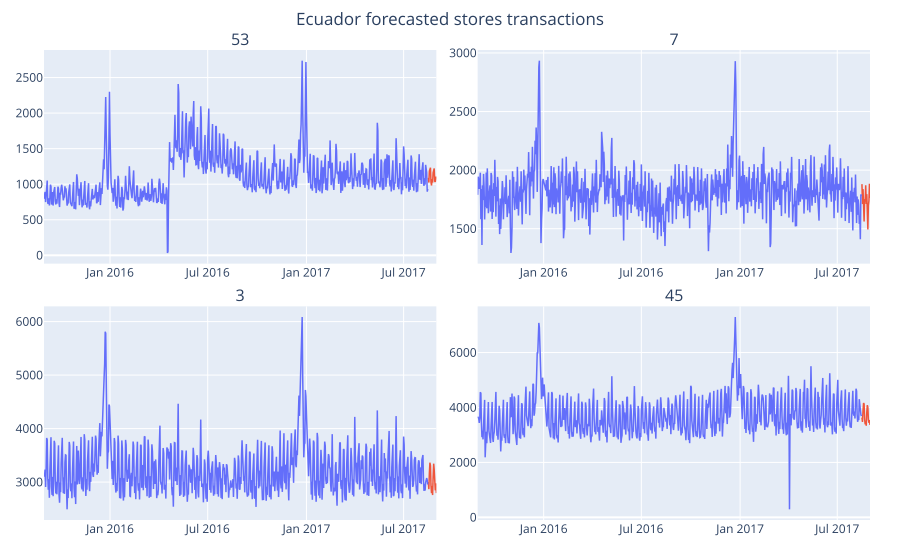

In [24]:
forecastedSeriesPlot(data=result, n_series=4, title=f"Ecuador forecasted stores {value}", seed=134)  # type: ignore

In [25]:
transactions = result.drop(columns="group")

# Sales

In [ ]:
# Proposed solution disclosing CommonPipeline stepwise strategy
X_exog_train = X_exog_train.join(oil).join(stores).join(transactions)
X_exog_test = X_exog_test.join(oil).join(stores).join(transactions)
value = "sales"
sales.head()

sales
store_nbr family     date             
1         AUTOMOTIVE 2015-08-31    6.0
                     2015-09-01    1.0
                     2015-09-02    4.0
                     2015-09-03    2.0
                     2015-09-04    0.0

## Multiindex reduction

In [27]:
# Replacing multiindex with a single index to avoid further pandas index manipulation issues
mapper = Mapper()
sales = mapper.fit_transform(sales)
X_exog_train = mapper.transform(X_exog_train)
X_exog_test = mapper.transform(X_exog_test)

## Classification

In [28]:
# Series behavior classification to define an appropriate processing and modeling
result = DemandClassifier().fit_transform(sales)
result["class"].value_counts()  # type: ignore

class
smooth          1076
erratic          353
intermittent     124
lumpy             85
Name: count, dtype: int64

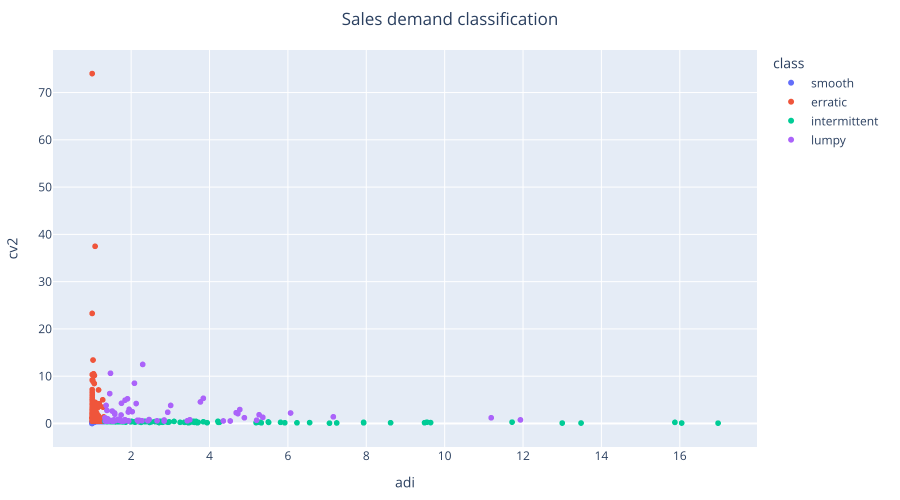

In [29]:
px.scatter(data_frame=result, x="adi", y="cv2", color="class").update_layout(
    title={
        "text": f"{value.capitalize()} demand classification",
        "x": 0.5,
    },
    margin=config.MARGIN,  # type: ignore
)

In [30]:
sales = (
    sales.join(result["class"])  # type: ignore
    .set_index("class", append=True)
    .reorder_levels(["class"] + sales.index.names)  # type: ignore
    .sort_index()
)

sales.head()

sales
class   index date              
erratic 9     2015-08-31  105.00
              2015-09-01  119.52
              2015-09-02  116.00
              2015-09-03  122.00
              2015-09-04  157.00

## Workflow per demand class

### Smooth & erratic

In [31]:
# Only smooth demand stepwise solution presented, the erratic is passing the same
# processing strategies and core fitting models
demand = "smooth"
temp = sales.loc[demand]

#### Plateau detection

In [ ]:
# Defining a temporal inactivity expressed as a plateau - zero values sequence with
# a specific length and leave only data which follows the last plateau if any defined
pld = PlateauDetector(w=2 * config.SEASONAL_PERIOD, value=0, truncate=True)  # type: ignore
temp = pld.fit_transform(temp)

#### Change point detection

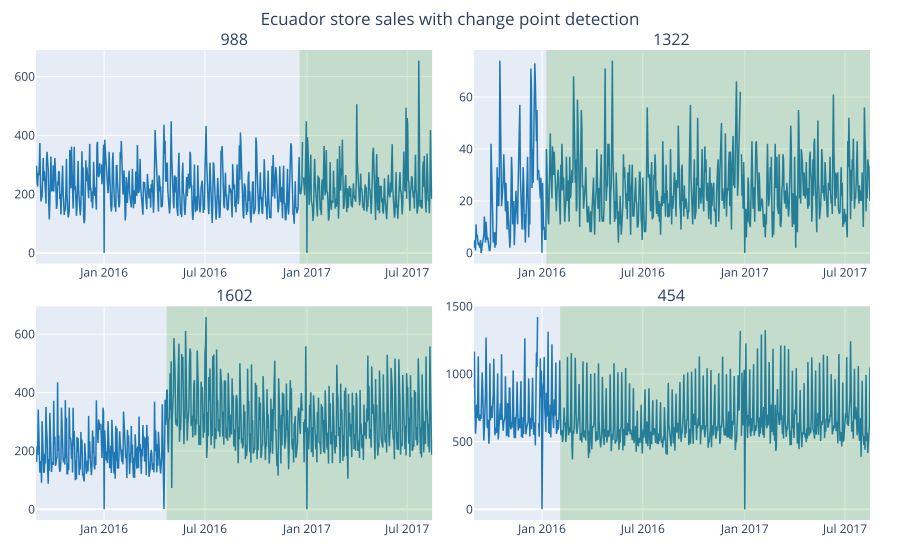

In [ ]:
# Defining an inflection point with specific requirements where the most significant
# trend behavior change was occured
seriesPlot(
    data=temp,  # type: ignore
    demand=demand,
    n_series=4,
    title=f"Ecuador store {value} with change point detection",
    w=config.MIN_LENGTH,  # type: ignore
    cpd=True,
    seed=666,
)

In [34]:
# Leave only data which follows right after this point if any exists
cpd = ChangePointDetector(w=config.MIN_LENGTH, truncate=True)  # type: ignore
temp = cpd.fit_transform(temp)

#### Outliers detection

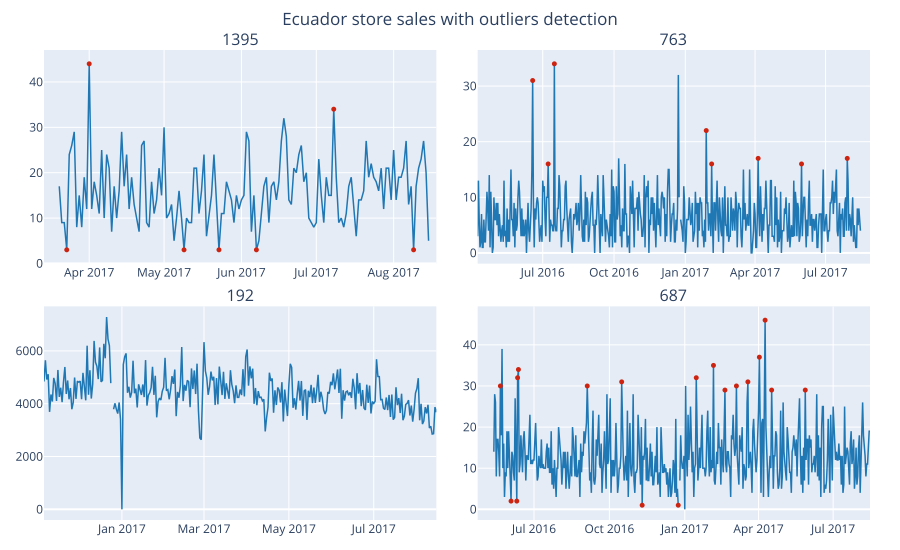

In [ ]:
# Defining outliers as a significant temporal demand with holidays and promotions
# data taking into account
seriesPlot(
    data=temp,  # type: ignore
    demand=demand,
    X_exog=X_exog_train,
    exog_column="on_promotion",
    n_series=4,
    title=f"Ecuador store {value} with outliers detection",
    w=2 * config.SEASONAL_PERIOD,  # type: ignore
    od=True,
    seed=69,
)

In [36]:
# Remove selected points that are not related to holidays and promotion days
od = OutlierDetector(demand=demand, exog_column="on_promotion", truncate=True)
temp = od.fit_transform(temp.join(X_exog_train))  # type: ignore

#### Missing values imputation

In [37]:
# Interpolating missing values if any present
index = temp.index  # type: ignore
temp = temp.groupby(index.names[0]).transform(  # type: ignore
    lambda x: x.interpolate(method="linear").bfill().ffill()
)

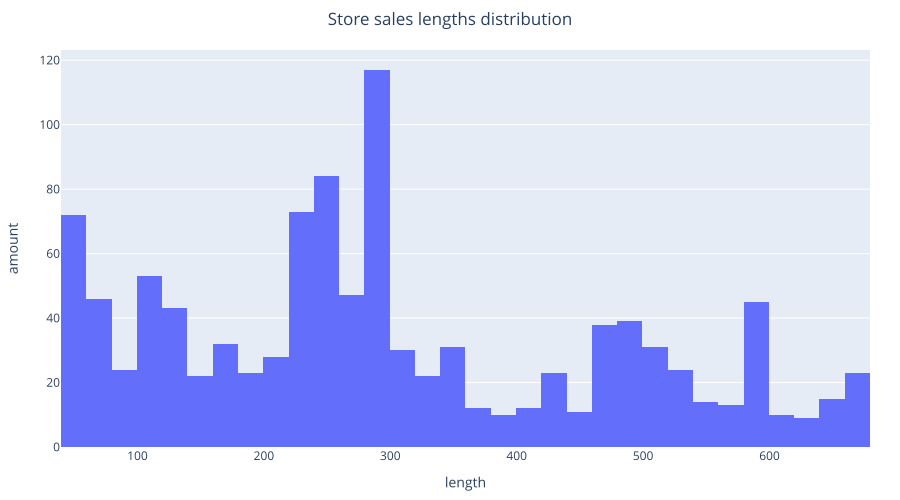

In [38]:
px.histogram(x=temp.groupby(index.names[0]).size(), nbins=50).update_layout(  # type: ignore
    margin=config.MARGIN,  # type: ignore
    title={
        "text": f"Store {value} lengths distribution",
        "x": 0.5,
    },
    xaxis_title="length",
    yaxis_title="amount",
)

#### Exogenous data transformation

In [39]:
# Expanding exogenous data with additional features based on the date index
ft = ExogenousDataTransformer()
X_temp_train = ft.fit_transform(X_exog_train)
X_temp_test = ft.transform(X_exog_test)
X_temp_train.head()  # type: ignore

on_promotion    oil  type  store_group  transactions  \
index date                                                               
0     2015-08-31           0.0  49.20   0.0         13.0        1785.0   
      2015-09-01           0.0  45.38   0.0         13.0        1769.0   
      2015-09-02           0.0  46.30   0.0         13.0        1892.0   
      2015-09-03           0.0  46.75   0.0         13.0        1744.0   
      2015-09-04           0.0  46.02   0.0         13.0        1771.0   

                  month_of_year  day_of_month  day_of_week  is_weekend  \
index date                                                               
0     2015-08-31            8.0          31.0          0.0         0.0   
      2015-09-01            9.0           1.0          1.0         0.0   
      2015-09-02            9.0           2.0          2.0         0.0   
      2015-09-03            9.0           3.0          3.0         0.0   
      2015-09-04            9.0           4.0          4.0         0.0   

                  is_holiday  is_wage  
index date                             
0     2015-08-31         0.0      1.0  
      2015-09-01         0.0      0.0  
      2015-09-02         0.0      0.0  
      2015-09-03         0.0      0.0  
      2015-09-04         0.0      0.0

#### Clustering

In [40]:
# Aligning exogenous variables with target by index
X_temp_train = temp[[]].join(X_temp_train)
X_temp_test = X_temp_test.loc[temp.droplevel(-1).index.unique()]

In [ ]:
# Clustering series with similar shape, statistics and magnitude to enhance the
# global forecasting quality per cluster
clusterer = SmoothErraticClusterer(w=90)

dir_path = Path.cwd().parent / "models"
path = dir_path / (
    "_".join([value, demand, clusterer.get_tag("object_type")])  # type: ignore
    + ".joblib"
)

if not Path.is_file(path):
    clusterer.fit(X=temp)
    dump(clusterer, path)
else:
    clusterer = load(path)

clusterer.metrics

,avg_sil_score,avg_ari,std_ari,std_inertia,score
29,0.182218,0.642190,0.089229,55.417483,0.089896
30,0.181241,0.628255,0.088579,54.761827,0.082678
28,0.184195,0.625363,0.086586,63.062303,0.000251
21,0.194501,0.627927,0.098090,67.964886,-0.052561
27,0.184061,0.623848,0.089556,68.974490,-0.063423
16,0.214956,0.719318,0.125611,79.874182,-0.097557
23,0.191086,0.620160,0.090473,72.491954,-0.099690
24,0.189381,0.626398,0.094052,74.448070,-0.117445
26,0.185434,0.632025,0.090553,77.822934,-0.144040
20,0.199483,0.632987,0.102218,78.293436,-0.152423


In [42]:
# Assigning cluster labels to instances as a primary index
labels = pd.Series(clusterer.labels, name="cluster").rename_axis("index")
temp = (
    temp.join(labels)
    .set_index("cluster", append=True)
    .reorder_levels(["cluster"] + index.names)  # type: ignore
    .sort_index()
)
X_temp_train = temp[[]].join(X_temp_train)
X_temp_test = (
    X_temp_test.join(labels)  # type: ignore
    .set_index("cluster", append=True)
    .reorder_levels(["cluster"] + index.names)  # type: ignore
    .sort_index()
)
labels.value_counts().head()

cluster
26    118
19    114
22     89
12     74
16     70
Name: count, dtype: int64

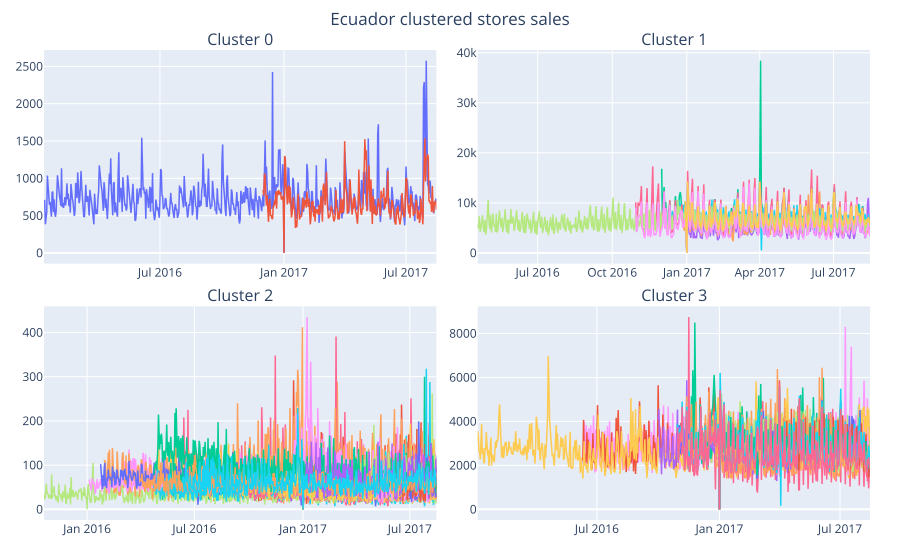

In [ ]:
# Visualizing clusters in order to evaluate homogeneity of their instances
# The loc was used to only control the output plot size
clusteredSeriesPlot(
    data=temp.loc[[*range(4)]], title=f"Ecuador clustered stores {value}"
)

In [44]:
temp.groupby("cluster").size().sort_values(ascending=False).head()

cluster
26    37252
19    36780
22    26423
20    22031
12    20999
dtype: int64

#### Modeling

In [ ]:
# Fitting forecasting model per cluster based on its size and with all exogenous
# data accomodation
forecaster = CommonForecaster(dir_path=dir_path, value=value, demand=demand)
forecaster.fit(y=temp, X=X_temp_train, fh=fh)

Successfully fitted sales smooth models:  23%|██▎       | 7/31 [00:02<00:07,  3.33it/s]

sales_smooth_forecaster_cluster_4.joblib best RMSLE score: 0.301
sales_smooth_forecaster_cluster_3.joblib best RMSLE score: 0.189
sales_smooth_forecaster_cluster_6.joblib best RMSLE score: 0.114
sales_smooth_forecaster_cluster_1.joblib best RMSLE score: 0.183
sales_smooth_forecaster_cluster_0_645.joblib best RMSLE score: 0.259
sales_smooth_forecaster_cluster_0_280.joblib best RMSLE score: 0.278
sales_smooth_forecaster_cluster_5.joblib best RMSLE score: 0.194
sales_smooth_forecaster_cluster_8.joblib best RMSLE score: 0.463
sales_smooth_forecaster_cluster_10.joblib best RMSLE score: 0.147
sales_smooth_forecaster_cluster_9.joblib best RMSLE score: 0.213
sales_smooth_forecaster_cluster_14.joblib best RMSLE score: 0.226
sales_smooth_forecaster_cluster_13.joblib best RMSLE score: 0.146
sales_smooth_forecaster_cluster_17.joblib best RMSLE score: 0.157
sales_smooth_forecaster_cluster_11.joblib best RMSLE score: 0.171
sales_smooth_forecaster_cluster_2.joblib best RMSLE score: 0.294
sales_smooth

Successfully fitted sales smooth models:  94%|█████████▎| 29/31 [00:03<00:00, 18.89it/s]

sales_smooth_forecaster_cluster_18.joblib best RMSLE score: 0.23
sales_smooth_forecaster_cluster_15.joblib best RMSLE score: 0.165
sales_smooth_forecaster_cluster_21.joblib best RMSLE score: 0.186
sales_smooth_forecaster_cluster_19.joblib best RMSLE score: 0.474
sales_smooth_forecaster_cluster_20.joblib best RMSLE score: 0.193
sales_smooth_forecaster_cluster_23.joblib best RMSLE score: 0.225
sales_smooth_forecaster_cluster_25.joblib best RMSLE score: 0.146
sales_smooth_forecaster_cluster_22.joblib best RMSLE score: 0.196
sales_smooth_forecaster_cluster_24_1215.joblib best RMSLE score: 0.165
sales_smooth_forecaster_cluster_24_1186.joblib best RMSLE score: 0.401
sales_smooth_forecaster_cluster_28.joblib best RMSLE score: 0.174
sales_smooth_forecaster_cluster_26.joblib best RMSLE score: 0.36
sales_smooth_forecaster_cluster_27.joblib best RMSLE score: 0.443


Successfully fitted sales smooth models: 100%|██████████| 31/31 [00:03<00:00,  9.82it/s]


CommonForecaster(demand='smooth',
                 dir_path=PosixPath('/Users/anderson/Education/ML/TimeSeries/Retail/models'),
                 value='sales')

In [46]:
forecasts = forecaster.predict(X=X_temp_test)
result = mapper.inverse_transform(
    pd.concat(
        [
            temp.assign(group="train"),
            forecasts.assign(group="forecast"),  # type: ignore
        ]
    ).droplevel(0)
)
result.head()

sales  group
store_nbr family   date                    
10        CLEANING 2016-01-11  697.0  train
                   2016-01-12  701.0  train
                   2016-01-13  385.0  train
                   2016-01-14  525.0  train
                   2016-01-15  543.0  train

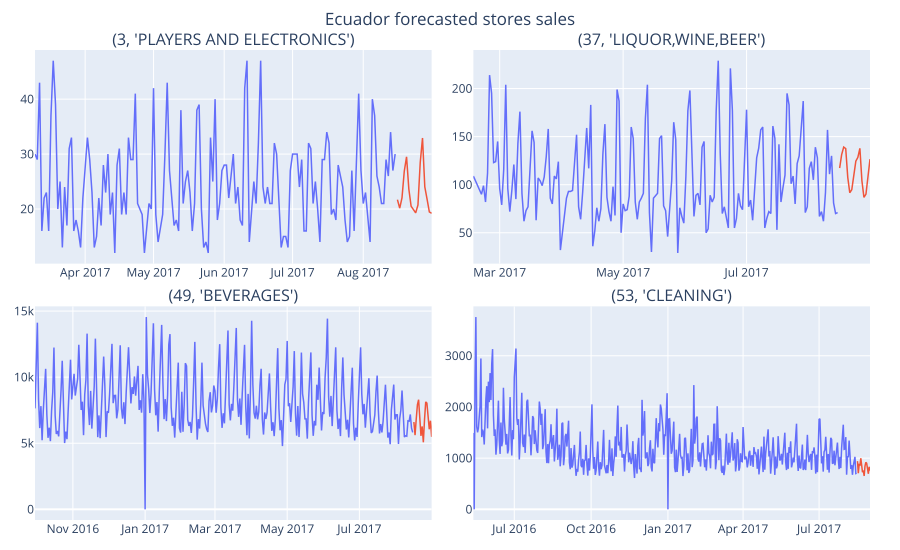

In [47]:
forecastedSeriesPlot(data=result, n_series=4, title=f"Ecuador forecasted stores {value}", seed=69)  # type: ignore

### Intermittent & lumpy

In [48]:
# Only intermittent demand stepwise solution presented, the lumpy is passing the same
# processing strategies and core fitting models
demand = "intermittent"
temp = sales.loc[demand]

#### Outliers Detection

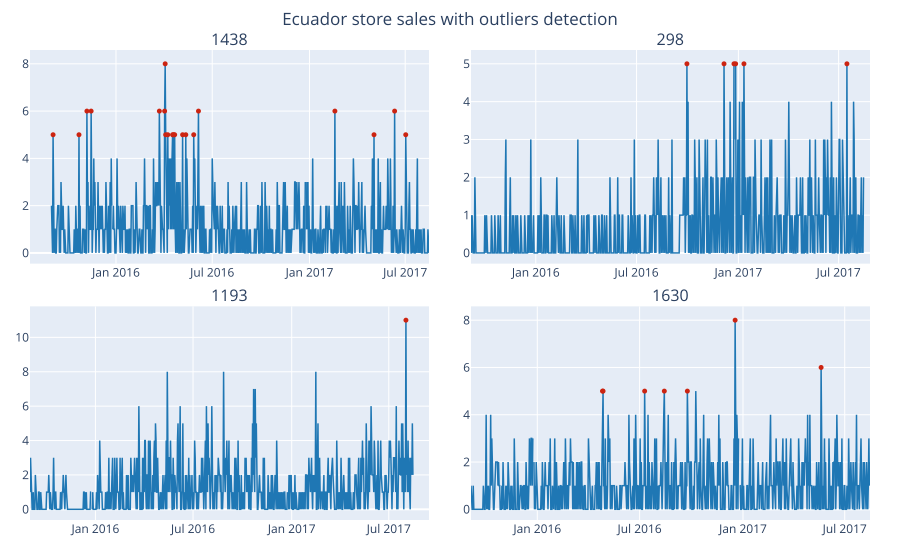

In [ ]:
# Defining outliers as a significant temporal demand with holidays and promotions
# data taking into account
seriesPlot(
    data=temp,  # type: ignore
    demand=demand,
    X_exog=X_exog_train,
    exog_column="on_promotion",
    n_series=4,
    title=f"Ecuador store {value} with outliers detection",
    w=2 * config.SEASONAL_PERIOD,  # type: ignore
    od=True,
    seed=69,
)

In [50]:
# Remove selected points that are not related to holidays and promotion days
od = OutlierDetector(demand=demand, exog_column="on_promotion", truncate=True)
temp = od.fit_transform(temp.join(X_exog_train))  # type: ignore

#### Missing values imputation

In [51]:
# Interpolating missing values if any present
index = temp.index  # type: ignore
temp = temp.groupby(temp.index.names[0]).transform(  # type: ignore
    lambda x: x.fillna(
        x.rolling(window=config.SEASONAL_PERIOD, min_periods=1).median()  # type: ignore
    ).fillna(0)
)

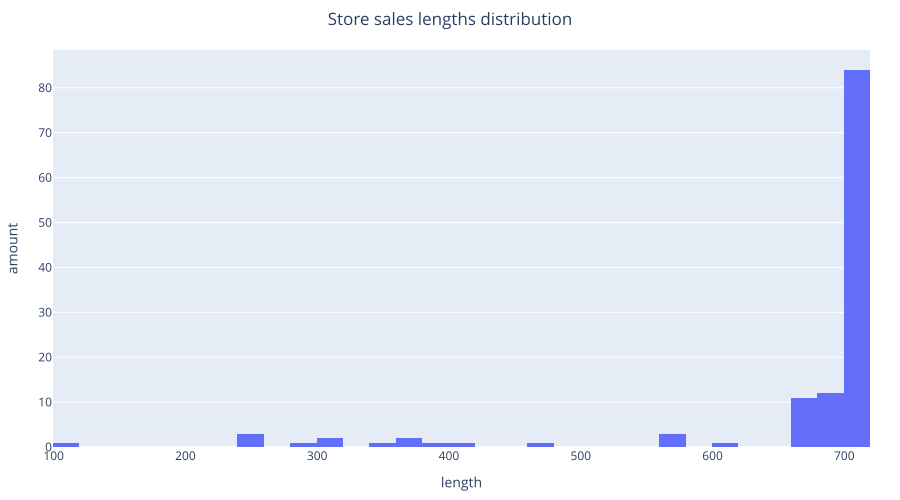

In [52]:
px.histogram(x=temp.groupby(index.names[0]).size(), nbins=50).update_layout(  # type: ignore
    margin=config.MARGIN,  # type: ignore
    title={
        "text": f"Store {value} lengths distribution",
        "x": 0.5,
    },
    xaxis_title="length",
    yaxis_title="amount",
)

#### Exogenous features transformation

In [53]:
# Expanding exogenous data with additional features based on the date index
ft = ExogenousDataTransformer()
X_temp_train = ft.fit_transform(X_exog_train)
X_temp_test = ft.transform(X_exog_test)
X_temp_train.head()  # type: ignore

on_promotion    oil  type  store_group  transactions  \
index date                                                               
0     2015-08-31           0.0  49.20   0.0         13.0        1785.0   
      2015-09-01           0.0  45.38   0.0         13.0        1769.0   
      2015-09-02           0.0  46.30   0.0         13.0        1892.0   
      2015-09-03           0.0  46.75   0.0         13.0        1744.0   
      2015-09-04           0.0  46.02   0.0         13.0        1771.0   

                  month_of_year  day_of_month  day_of_week  is_weekend  \
index date                                                               
0     2015-08-31            8.0          31.0          0.0         0.0   
      2015-09-01            9.0           1.0          1.0         0.0   
      2015-09-02            9.0           2.0          2.0         0.0   
      2015-09-03            9.0           3.0          3.0         0.0   
      2015-09-04            9.0           4.0          4.0         0.0   

                  is_holiday  is_wage  
index date                             
0     2015-08-31         0.0      1.0  
      2015-09-01         0.0      0.0  
      2015-09-02         0.0      0.0  
      2015-09-03         0.0      0.0  
      2015-09-04         0.0      0.0

#### Clustering

In [54]:
# Aligning exogenous variables with target by index
X_temp_train = temp[[]].join(X_temp_train)
X_temp_test = X_temp_test.loc[temp.droplevel(-1).index.unique()]

In [ ]:
# Clustering series with similar shape, statistics and magnitude to enhance the
# global forecasting quality per cluster
clusterer = IntermittentLumpyClusterer()

dir_path = Path.cwd().parent / "models"
path = dir_path / (
    "_".join([value, demand, clusterer.get_tag("object_type")])  # type: ignore
    + ".joblib"
)

if not Path.is_file(path):
    clusterer.fit(X=temp)
    dump(clusterer, path)
else:
    clusterer = load(path)

clusterer.metrics

,avg_sil_score,avg_ari,std_ari,std_inertia,score
6,0.356655,0.973609,0.074536,0.682463,1.070576
5,0.364571,0.955136,0.096944,0.824031,1.032237
11,0.344992,0.877097,0.073223,2.888016,0.947490
10,0.338943,0.848978,0.070290,2.184134,0.926318
9,0.334474,0.815879,0.086550,1.989196,0.876673
7,0.312788,0.831323,0.109560,1.170345,0.866454
8,0.324566,0.789315,0.093542,1.777971,0.840276


In [56]:
# Assigning cluster labels to instances as a primary index
labels = pd.Series(clusterer.labels, name="cluster").rename_axis("index")
temp = (
    temp.join(labels)
    .set_index("cluster", append=True)
    .reorder_levels(["cluster"] + index.names)  # type: ignore
    .sort_index()
)
X_temp_train = temp[[]].join(X_temp_train)
X_temp_test = (
    X_temp_test.join(labels)  # type: ignore
    .set_index("cluster", append=True)
    .reorder_levels(["cluster"] + index.names)  # type: ignore
    .sort_index()
)
labels.value_counts()

cluster
2    51
0    46
3    15
1     7
4     4
5     1
Name: count, dtype: int64

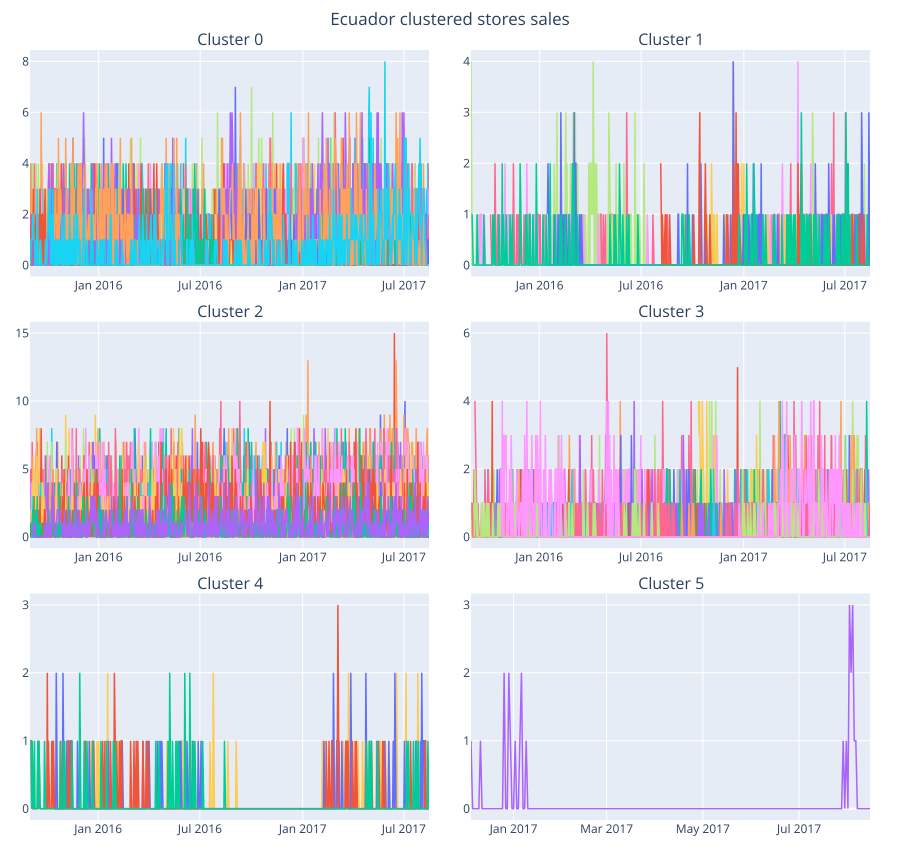

In [57]:
# Visualizing clusters in order to evaluate homogeneity of their instances
clusteredSeriesPlot(data=temp, title=f"Ecuador clustered stores {value}")

In [58]:
temp.groupby(level=0).size().sort_values(ascending=False)

cluster
2    34952
0    30491
3     9532
1     4061
4     2776
5      254
dtype: int64

#### Modeling

In [ ]:
# Fitting forecasting model per cluster based on its size and with all exogenous
# data accomodation

forecaster = CommonForecaster(dir_path=dir_path, value=value, demand=demand)
forecaster.fit(y=temp, X=X_temp_train, fh=fh)

Successfully fitted sales intermittent models:  17%|█▋        | 1/6 [00:01<00:05,  1.16s/it]

sales_intermittent_forecaster_cluster_1.joblib best RMSLE score: 0.274
sales_intermittent_forecaster_cluster_5_90.joblib best RMSLE score: 0.528
sales_intermittent_forecaster_cluster_3.joblib best RMSLE score: 0.348
sales_intermittent_forecaster_cluster_0.joblib best RMSLE score: 0.388
sales_intermittent_forecaster_cluster_4.joblib best RMSLE score: 0.268
sales_intermittent_forecaster_cluster_2.joblib best RMSLE score: 0.525


Successfully fitted sales intermittent models: 100%|██████████| 6/6 [00:01<00:00,  4.47it/s]


CommonForecaster(demand='intermittent',
                 dir_path=PosixPath('/Users/anderson/Education/ML/TimeSeries/Retail/models'),
                 n_jobs=6, value='sales')

In [60]:
forecasts = forecaster.predict(X=X_temp_test)
result = mapper.inverse_transform(
    pd.concat(
        [
            temp.assign(group="train"),
            forecasts.assign(group="forecast"),  # type: ignore
        ]
    ).droplevel(0)
)
result.head()

sales  group
store_nbr family          date                    
4         HOME APPLIANCES 2015-09-06    2.0  train
                          2015-09-07    0.0  train
                          2015-09-08    1.0  train
                          2015-09-09    1.0  train
                          2015-09-10    1.0  train

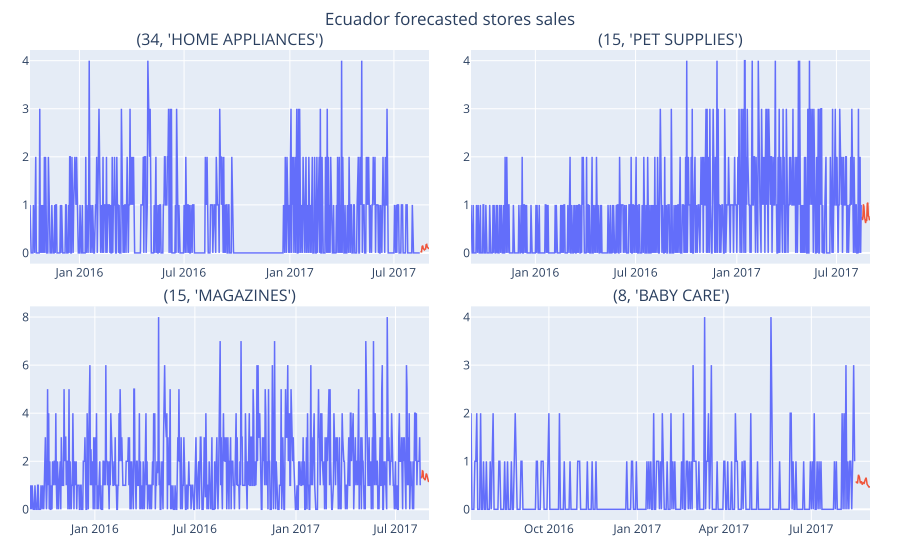

In [61]:
forecastedSeriesPlot(data=result, n_series=4, title=f"Ecuador forecasted stores {value}", seed=666)  # type: ignore

## End-to-end forecasting pipeline

In [ ]:
# To fit models for other demand classes the main e2e-model with all described above
# steps in a single fit/predict pipeline is used

# To apply it some inverse transformations are required returning to original data
sales = mapper.inverse_transform(X=sales.droplevel(0))
X_exog_train = mapper.inverse_transform(X=X_exog_train)
X_exog_test = mapper.inverse_transform(X=X_exog_test)

In [63]:
forecaster = E2EForecaster()
forecaster.fit(y=sales, X=X_exog_train, fh=fh)

Sales smooth series successfully transformed!
Sales smooth clusterer successfully fitted!


Successfully fitted sales smooth models:   0%|          | 0/31 [00:00<?, ?it/s]

sales_smooth_forecaster_cluster_1.joblib best RMSLE score: 0.183


Successfully fitted sales smooth models:  48%|████▊     | 15/31 [00:00<00:00, 77.25it/s]

sales_smooth_forecaster_cluster_0_645.joblib best RMSLE score: 0.259
sales_smooth_forecaster_cluster_5.joblib best RMSLE score: 0.194
sales_smooth_forecaster_cluster_2.joblib best RMSLE score: 0.294
sales_smooth_forecaster_cluster_0_280.joblib best RMSLE score: 0.278
sales_smooth_forecaster_cluster_8.joblib best RMSLE score: 0.463
sales_smooth_forecaster_cluster_6.joblib best RMSLE score: 0.114
sales_smooth_forecaster_cluster_7.joblib best RMSLE score: 0.188
sales_smooth_forecaster_cluster_9.joblib best RMSLE score: 0.213
sales_smooth_forecaster_cluster_10.joblib best RMSLE score: 0.147
sales_smooth_forecaster_cluster_11.joblib best RMSLE score: 0.171
sales_smooth_forecaster_cluster_13.joblib best RMSLE score: 0.146
sales_smooth_forecaster_cluster_14.joblib best RMSLE score: 0.226
sales_smooth_forecaster_cluster_12.joblib best RMSLE score: 0.447
sales_smooth_forecaster_cluster_17.joblib best RMSLE score: 0.157
sales_smooth_forecaster_cluster_16.joblib best RMSLE score: 0.21
sales_smoot

...

Successfully fitted sales lumpy models:  25%|██▌       | 1/4 [00:06<00:18,  6.09s/it]

sales_lumpy_forecaster_cluster_3_303.joblib best RMSLE score: 1.164
sales_lumpy_forecaster_cluster_1.joblib best RMSLE score: 0.285
sales_lumpy_forecaster_cluster_0.joblib best RMSLE score: 0.806
sales_lumpy_forecaster_cluster_2.joblib best RMSLE score: 0.541


Successfully fitted sales lumpy models: 100%|██████████| 4/4 [00:06<00:00,  1.57s/it]


Sales lumpy forecaster successfully fitted!


E2EForecaster()

In [64]:
forecasts = forecaster.predict(X=X_exog_test)
result = pd.concat(
    [
        sales.assign(group="train"),
        forecasts.assign(group="forecast"),  # type: ignore
    ]
)
result.head()

sales  group
store_nbr family       date                     
1         FROZEN FOODS 2015-08-31  105.00  train
                       2015-09-01  119.52  train
                       2015-09-02  116.00  train
                       2015-09-03  122.00  train
                       2015-09-04  157.00  train

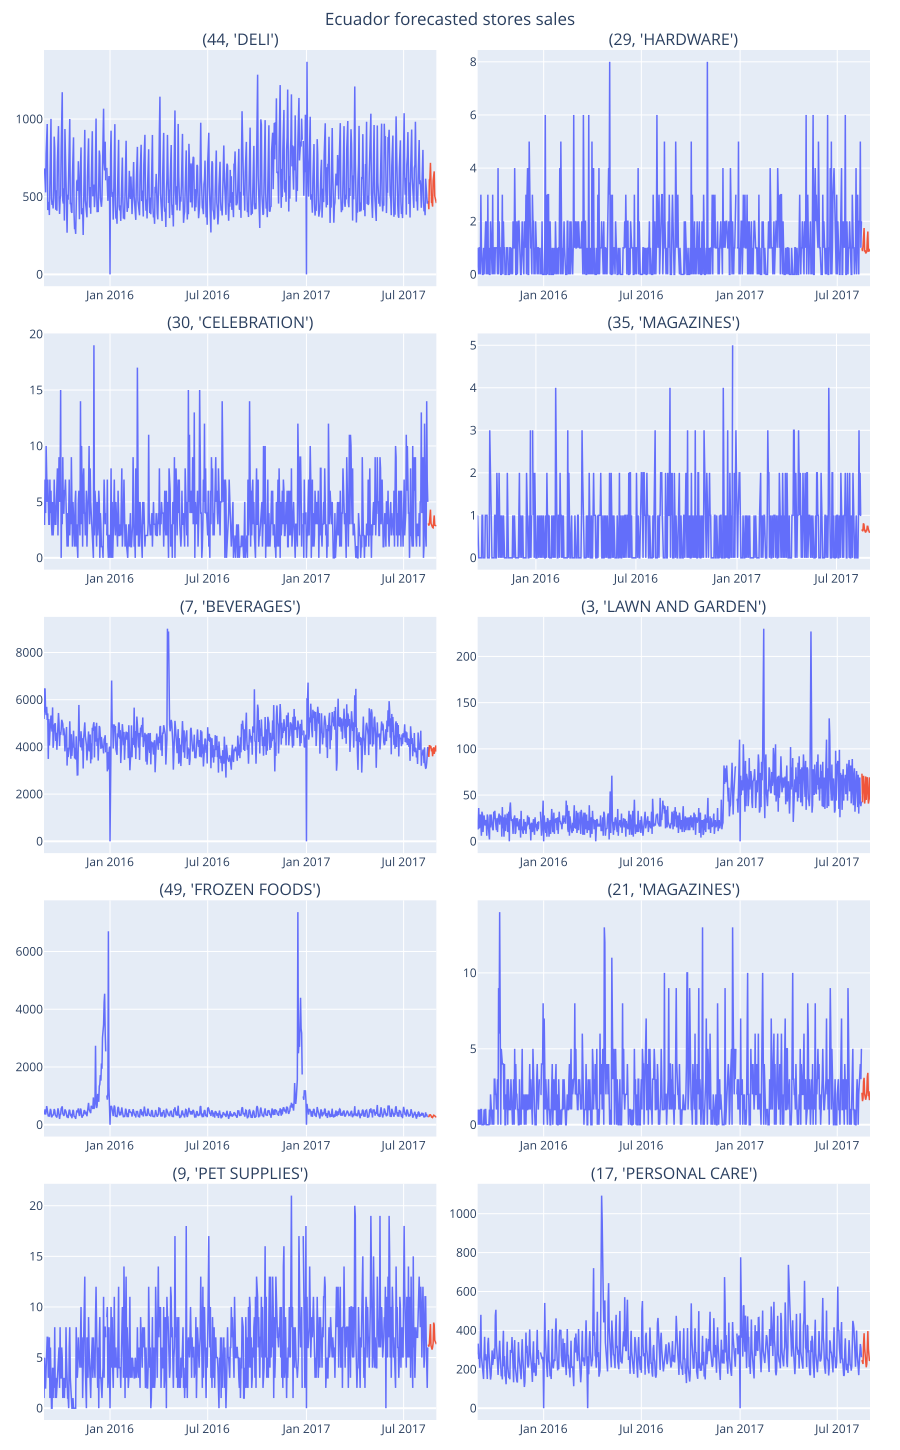

In [65]:
forecastedSeriesPlot(data=result, n_series=10, title=f"Ecuador forecasted stores {value}", seed=666)  # type: ignore

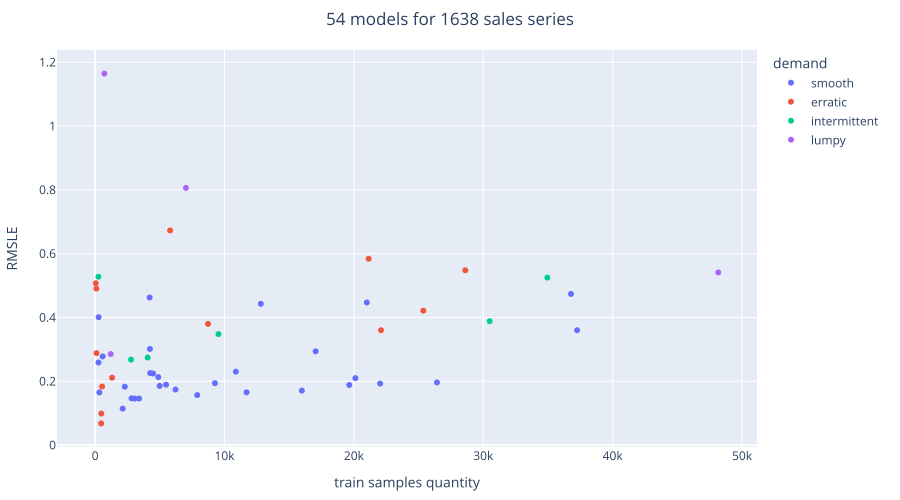

In [66]:
# Post fit core models quality analysis based on train sample size and demand class
table = pd.DataFrame()
for demand in forecaster.models:
    for group in forecaster.models[demand].forecaster.models:
        t = load(forecaster.models[demand].forecaster.models[group])
        del t["model"]
        t["demand"] = demand
        t["group"] = group
        table = pd.concat([table, pd.Series(t).to_frame().T])

px.scatter(data_frame=table, x="y_size", y="score", color="demand").update_layout(
    title={
        "text": f"{table.shape[0]} models for {result.droplevel(-1).index.nunique()} {value} series",
        "x": 0.5,
    },
    xaxis_title="train samples quantity",
    yaxis_title="RMSLE",
    margin=config.MARGIN,  # type: ignore
)

# Submission

In [67]:
# Updating submission with died products zeros fillling
test = pd.read_csv(
    filepath_or_buffer="../data/raw/test.csv",
    parse_dates=["date"],
    index_col=["id", "store_nbr", "family", "date"],
    engine="pyarrow",
)[[]]
submission = pd.read_csv(
    filepath_or_buffer="../data/raw/sample_submission.csv",
    index_col="id",
    engine="pyarrow",
)

submission = (
    submission[[]].join(test.join(result[value]).fillna(0)).reset_index()[["id", value]]
)
submission.head()

,id,sales
0,3000888,3.649250
1,3000889,0.000000
2,3000890,5.055916
3,3000891,2293.923254
4,3000892,0.000000


In [200]:
submission.to_csv("../data/raw/sample_submission.csv", index=False)